# Annotate SNP major/minor alleles and the AD direction of the minor allele

This notebook annotates an MPRA SNP table using the Bellenguez et al. (2022) Alzheimer's disease GWAS summary statistics.

It will:

1. Load the SNP table.
2. Download the official Bellenguez GWAS Catalog summary-statistics file if needed.
3. Match variants by rsID first and GRCh38 coordinate second.
4. Preserve the `Major` and `Minor` alleles already defined in the input table.
5. Convert the Bellenguez GWAS effect to the **input minor allele** direction.
6. Use the Bellenguez effect-allele frequency, when available, to independently infer major/minor alleles and flag inconsistencies.
7. Export an annotated CSV and Excel workbook.

Interpretation of `Bellenguez_input_minor_allele_AD_direction`:

- `risk`: the input minor allele has a positive AD log-odds effect.
- `protective`: the input minor allele has a negative AD log-odds effect.
- `unresolved`: the SNP was not found, the allele pair does not match, or an effect estimate is unavailable.

**Important:** direction and statistical significance are separate. Always review the Bellenguez P value.

Bellenguez GWAS Catalog accession: `GCST90027158`

In [1]:
# Run only if required packages are missing.
%pip install -q pandas numpy openpyxl

Note: you may need to restart the kernel to use updated packages.


In [1]:
from pathlib import Path
from urllib.request import urlretrieve
import re

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

## 1. Configuration for the T7 external drive

All input files are configured under:

```text
/Volumes/T7/mpra3_lib_analysis/indexing
```

The Bellenguez annotation workflow uses:

- the complete SNP annotation table as `INPUT_PATH`
- the local Bellenguez GWAS summary-statistics file as `GWAS_PATH`

The two additional CSV files are also registered as optional paths for later merging. Because the GWAS file already exists locally, the notebook will skip downloading it.

In Python, spaces inside `Path("...")` strings do **not** need shell-style backslash escaping.


In [2]:
# -----------------------------
# Base directory on your external T7 drive
# -----------------------------
#
# In Python Path strings, keep spaces as normal characters.
# Do NOT use shell-style escaping such as "\ ".
#
BASE_DIR = Path("/Volumes/T7/mpra3_lib_analysis/indexing")

# -----------------------------
# Main inputs used by this notebook
# -----------------------------

# Complete SNP annotation table. This is the table that will be annotated.
INPUT_PATH = BASE_DIR / (
    "SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_"
    "Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_catlas_"
    "with_all_peakfiles_variant_category_20260310.csv"
)

# Bellenguez et al. 2022 AD GWAS summary statistics.
# Because the file is already on your T7 drive, the notebook will use the
# local copy and will not download it again.
GWAS_PATH = BASE_DIR / "GCST90027158_buildGRCh38.tsv.gz"

# Official download URL retained as a fallback only.
GWAS_URL = (
    "https://ftp.ebi.ac.uk/pub/databases/gwas/summary_statistics/"
    "GCST90027001-GCST90028000/GCST90027158/"
    "GCST90027158_buildGRCh38.tsv.gz"
)

# -----------------------------
# Additional tables in the same directory
# -----------------------------
#
# These are registered here for convenience but are not required for the
# Bellenguez direction annotation workflow below.
#
ALL_SNPS_PATH = BASE_DIR / "All_SNPs.xlsx - Dmitry 148.csv"
PROTECTIVE_SNVS_PATH = BASE_DIR / "protective SNVs prioritized - share.csv"

# -----------------------------
# Outputs
# -----------------------------

OUTPUT_PREFIX = INPUT_PATH.with_name(INPUT_PATH.stem + "_Bellenguez_AD_direction")
OUTPUT_CSV = OUTPUT_PREFIX.with_suffix(".csv")
OUTPUT_XLSX = OUTPUT_PREFIX.with_suffix(".xlsx")

# -----------------------------
# Input column names in the complete SNP table
# -----------------------------

INPUT_RSID_COL = "rsid"
INPUT_CHR_COL = "chr"
INPUT_POS_COL = "snp"       # GRCh38 coordinate
INPUT_MAJOR_COL = "Major"
INPUT_MINOR_COL = "Minor"

# Read GWAS in chunks to avoid loading the entire file into memory.
CHUNK_SIZE = 500_000
GWAS_SIGNIFICANCE_THRESHOLD = 5e-8

# -----------------------------
# Confirm that the configured paths exist
# -----------------------------

configured_paths = {
    "Complete SNP table": INPUT_PATH,
    "Bellenguez GWAS": GWAS_PATH,
    "Optional All_SNPs table": ALL_SNPS_PATH,
    "Optional protective SNVs table": PROTECTIVE_SNVS_PATH,
}

for label, path in configured_paths.items():
    status = "FOUND" if path.exists() else "NOT FOUND"
    print(f"{label:32s} [{status}]")
    print(f"  {path}")

print("\nOutputs will be saved as:")
print(" ", OUTPUT_CSV)
print(" ", OUTPUT_XLSX)


Complete SNP table               [FOUND]
  /Volumes/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_catlas_with_all_peakfiles_variant_category_20260310.csv
Bellenguez GWAS                  [FOUND]
  /Volumes/T7/mpra3_lib_analysis/indexing/GCST90027158_buildGRCh38.tsv.gz
Optional All_SNPs table          [FOUND]
  /Volumes/T7/mpra3_lib_analysis/indexing/All_SNPs.xlsx - Dmitry 148.csv
Optional protective SNVs table   [FOUND]
  /Volumes/T7/mpra3_lib_analysis/indexing/protective SNVs prioritized - share.csv

Outputs will be saved as:
  /Volumes/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_catlas_with_all_peakfiles_variant_category_20260310_Bellenguez_AD_direction.csv
  /Volumes/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genom

## 2. Helper functions

In [3]:
def normalize_rsid(value):
    # Return a lowercase rsID such as rs1234, or None.
    if pd.isna(value):
        return None
    value = str(value).strip().lower()
    return value if re.fullmatch(r"rs\d+", value) else None


def normalize_chr(value):
    # Return chromosome label without chr prefix, for example 1, 19, X.
    if pd.isna(value):
        return None
    value = re.sub(r"^chr", "", str(value).strip(), flags=re.IGNORECASE)
    if value.endswith(".0"):
        value = value[:-2]
    value = value.upper()
    return value if value else None


def normalize_pos(value):
    # Return integer genomic position, or None.
    if pd.isna(value):
        return None
    try:
        return int(float(value))
    except (TypeError, ValueError):
        return None


def normalize_allele(value):
    # Normalize an allele string. This also works for short indels.
    if pd.isna(value):
        return None
    value = str(value).strip().upper()
    return None if value in {"", "NA", "NAN", "NONE", "."} else value


def coordinate_key(chromosome, position):
    chrom = normalize_chr(chromosome)
    pos = normalize_pos(position)
    return None if chrom is None or pos is None else f"{chrom}:{pos}"


def download_with_progress(url, destination):
    # Download once and reuse the local file on later runs.
    destination = Path(destination)
    if destination.exists() and destination.stat().st_size > 0:
        print(
            f"Using existing GWAS file: {destination} "
            f"({destination.stat().st_size / 1e6:.1f} MB)"
        )
        return

    print("Downloading Bellenguez GWAS summary statistics...")
    print(url)
    last_percent = {"value": -1}

    def reporthook(block_num, block_size, total_size):
        downloaded = block_num * block_size
        if total_size > 0:
            percent = min(100, int(downloaded * 100 / total_size))
            if percent >= last_percent["value"] + 5 or percent == 100:
                last_percent["value"] = percent
                print(f"  {percent:3d}%")

    urlretrieve(url, destination, reporthook=reporthook)
    print(f"Saved: {destination} ({destination.stat().st_size / 1e6:.1f} MB)")


def pick_column(columns, aliases, required=False):
    # Find the first matching column using case-insensitive aliases.
    lower_to_actual = {str(col).lower(): col for col in columns}
    for alias in aliases:
        if alias.lower() in lower_to_actual:
            return lower_to_actual[alias.lower()]
    if required:
        raise KeyError(
            f"Required column not found. Tried aliases: {aliases}\n"
            f"Available columns: {list(columns)}"
        )
    return None


def direction_from_beta(beta_minor):
    if pd.isna(beta_minor):
        return "unresolved"
    if beta_minor > 0:
        return "risk"
    if beta_minor < 0:
        return "protective"
    return "no_effect_estimate"

## 3. Load the input SNP table

Some variants appear in multiple MPRA constructs. The notebook annotates every row and later creates a deduplicated variant-level sheet.

In [4]:
if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Input file not found: {INPUT_PATH}\n"
        "Check that the T7 drive is mounted and that INPUT_PATH is correct."
    )

variants = pd.read_csv(INPUT_PATH, low_memory=False)
variants["_input_row_id"] = np.arange(len(variants))

required_input_columns = [
    INPUT_RSID_COL,
    INPUT_CHR_COL,
    INPUT_POS_COL,
    INPUT_MAJOR_COL,
    INPUT_MINOR_COL,
]
missing_input_columns = [
    col for col in required_input_columns if col not in variants.columns
]
if missing_input_columns:
    raise KeyError(
        f"Missing required input columns: {missing_input_columns}\n"
        f"Available columns include: {variants.columns.tolist()[:80]}"
    )

variants["_input_rsid_norm"] = variants[INPUT_RSID_COL].map(normalize_rsid)
variants["_input_coord_key"] = [
    coordinate_key(chrom, pos)
    for chrom, pos in zip(variants[INPUT_CHR_COL], variants[INPUT_POS_COL])
]
variants["_input_major_norm"] = variants[INPUT_MAJOR_COL].map(normalize_allele)
variants["_input_minor_norm"] = variants[INPUT_MINOR_COL].map(normalize_allele)

print(f"Input rows: {len(variants):,}")
print(f"Rows with valid rsIDs: {variants['_input_rsid_norm'].notna().sum():,}")
print(f"Unique rsIDs: {variants['_input_rsid_norm'].dropna().nunique():,}")
print(f"Rows with GRCh38 coordinates: {variants['_input_coord_key'].notna().sum():,}")

variants[[
    INPUT_RSID_COL,
    INPUT_CHR_COL,
    INPUT_POS_COL,
    INPUT_MAJOR_COL,
    INPUT_MINOR_COL,
    "_input_rsid_norm",
    "_input_coord_key",
]].head()

Input rows: 855
Rows with valid rsIDs: 844
Unique rsIDs: 588
Rows with GRCh38 coordinates: 855


/var/folders/sh/7r2k6xws40df6nh1bf5t_1x40000gn/T/ipykernel_31925/784933016.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  variants["_input_row_id"] = np.arange(len(variants))
/var/folders/sh/7r2k6xws40df6nh1bf5t_1x40000gn/T/ipykernel_31925/784933016.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  variants["_input_rsid_norm"] = variants[INPUT_RSID_COL].map(normalize_rsid)
/var/folders/sh/7r2k6xws40df6nh1bf5t_1x40000gn/T/ipykernel_31925/784933016.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually

,rsid,chr,snp,Major,Minor,_input_rsid_norm,_input_coord_key
0,cg03073402,chr19,42927676,C,G,NaN,19:42927676
1,cg03169557,chr16,89598950,C,G,NaN,16:89598950
2,cg05030077,chr16,2255199,C,G,NaN,16:2255199
3,cg05066959,chr8,41519308,C,G,NaN,8:41519308
4,cg05228284,chr19,2720847,C,G,NaN,19:2720847


## 4. Download and inspect the Bellenguez GWAS file

The file is downloaded only if it is not already in the notebook directory.

In [5]:
download_with_progress(GWAS_URL, GWAS_PATH)

gwas_header = pd.read_csv(
    GWAS_PATH,
    sep="\t",
    compression="gzip",
    nrows=0,
).columns.tolist()

print(f"Bellenguez GWAS columns ({len(gwas_header)}):")
print(gwas_header)

Using existing GWAS file: /Volumes/T7/mpra3_lib_analysis/indexing/GCST90027158_buildGRCh38.tsv.gz (755.2 MB)
Bellenguez GWAS columns (17):
['variant_id', 'p_value', 'chromosome', 'base_pair_location', 'effect_allele', 'other_allele', 'effect_allele_frequency', 'odds_ratio', 'ci_lower', 'ci_upper', 'beta', 'standard_error', 'n_cases', 'n_controls', 'het_isq', 'het_pvalue', 'variant_alternate_id']


## 5. Read only relevant Bellenguez records

The code accepts standardized GWAS Catalog columns and common aliases. It filters by the SNP list while iterating through the compressed file.

In [6]:
GWAS_COLUMN_ALIASES = {
    "rsid": ["rsid", "variant_id", "snp", "markername"],
    "chromosome": ["chromosome", "chr", "chrom"],
    "position": ["base_pair_location", "position", "pos", "bp"],
    "effect_allele": ["effect_allele", "ea", "a1", "alt"],
    "other_allele": ["other_allele", "oa", "a2", "ref"],
    "effect_allele_frequency": [
        "effect_allele_frequency", "eaf", "effect_allele_freq", "af"
    ],
    "beta": ["beta", "effect_size", "estimate"],
    "odds_ratio": ["odds_ratio", "or"],
    "p_value": ["p_value", "pvalue", "p", "pval"],
    "standard_error": ["standard_error", "se", "stderr"],
}

gwas_col = {
    key: pick_column(
        gwas_header,
        aliases,
        required=(key in {
            "rsid", "chromosome", "position", "effect_allele", "other_allele", "p_value"
        }),
    )
    for key, aliases in GWAS_COLUMN_ALIASES.items()
}

if gwas_col["beta"] is None and gwas_col["odds_ratio"] is None:
    raise KeyError("The GWAS file contains neither beta nor odds_ratio.")

print("Mapped Bellenguez columns:")
for key, value in gwas_col.items():
    print(f"  {key:26s} -> {value}")

usecols = sorted({col for col in gwas_col.values() if col is not None})
target_rsids = set(variants["_input_rsid_norm"].dropna())
target_coords = set(variants["_input_coord_key"].dropna())
retained_chunks = []

for chunk_index, chunk in enumerate(
    pd.read_csv(
        GWAS_PATH,
        sep="\t",
        compression="gzip",
        usecols=usecols,
        chunksize=CHUNK_SIZE,
        low_memory=False,
    ),
    start=1,
):
    rename_map = {
        actual_name: standardized_name
        for standardized_name, actual_name in gwas_col.items()
        if actual_name is not None
    }
    chunk = chunk.rename(columns=rename_map)
    chunk["_gwas_rsid_norm"] = chunk["rsid"].map(normalize_rsid)
    chunk["_gwas_coord_key"] = [
        coordinate_key(chrom, pos)
        for chrom, pos in zip(chunk["chromosome"], chunk["position"])
    ]
    keep = (
        chunk["_gwas_rsid_norm"].isin(target_rsids)
        | chunk["_gwas_coord_key"].isin(target_coords)
    )
    if keep.any():
        retained_chunks.append(chunk.loc[keep].copy())
    if chunk_index % 10 == 0:
        print(f"Processed {chunk_index:,} chunks...")

if retained_chunks:
    gwas_subset = pd.concat(retained_chunks, ignore_index=True)
else:
    gwas_subset = pd.DataFrame()

print(f"Retained Bellenguez rows relevant to input: {len(gwas_subset):,}")
gwas_subset.head()

Mapped Bellenguez columns:
  rsid                       -> variant_id
  chromosome                 -> chromosome
  position                   -> base_pair_location
  effect_allele              -> effect_allele
  other_allele               -> other_allele
  effect_allele_frequency    -> effect_allele_frequency
  beta                       -> beta
  odds_ratio                 -> odds_ratio
  p_value                    -> p_value
  standard_error             -> standard_error
Processed 10 chunks...
Processed 20 chunks...
Processed 30 chunks...
Processed 40 chunks...
Retained Bellenguez rows relevant to input: 463


,rsid,p_value,chromosome,position,effect_allele,other_allele,effect_allele_frequency,odds_ratio,beta,standard_error,_gwas_rsid_norm,_gwas_coord_key
0,rs72652926,0.00005,1,20852094,T,C,0.4455,0.967,-0.0331,0.0082,rs72652926,1:20852094
1,rs150840445,0.06080,1,41782299,A,G,0.0102,1.091,0.0873,0.0465,rs150840445,1:41782299
2,rs561236905,0.48430,1,101453799,A,G,0.0024,1.069,0.0667,0.0954,rs561236905,1:101453799
3,rs79106675,0.90640,1,101453935,T,C,0.9995,1.031,0.0305,0.2596,rs79106675,1:101453935
4,rs115702818,0.18860,1,101454018,A,G,0.9974,1.124,0.1169,0.0889,rs115702818,1:101454018


## 6. Normalize Bellenguez alleles and effect estimates

If a beta is unavailable but an odds ratio is present, the code converts the odds ratio to log odds using `beta = log(OR)`.

In [7]:
# Ensure optional GWAS columns exist even if absent from the source file.
for optional_col in [
    "effect_allele_frequency", "beta", "odds_ratio", "standard_error"
]:
    if optional_col not in gwas_subset.columns:
        gwas_subset[optional_col] = np.nan

# Ensure required columns also exist when zero rows matched.
for required_col in [
    "rsid", "chromosome", "position", "effect_allele", "other_allele", "p_value",
    "_gwas_rsid_norm", "_gwas_coord_key"
]:
    if required_col not in gwas_subset.columns:
        gwas_subset[required_col] = pd.Series(dtype="object")

gwas_subset["_gwas_effect_allele_norm"] = gwas_subset["effect_allele"].map(normalize_allele)
gwas_subset["_gwas_other_allele_norm"] = gwas_subset["other_allele"].map(normalize_allele)
gwas_subset["_gwas_p_value"] = pd.to_numeric(gwas_subset["p_value"], errors="coerce")
gwas_subset["_gwas_eaf"] = pd.to_numeric(gwas_subset["effect_allele_frequency"], errors="coerce")
gwas_subset["_gwas_beta_effect"] = pd.to_numeric(gwas_subset["beta"], errors="coerce")
gwas_subset["_gwas_or_effect"] = pd.to_numeric(gwas_subset["odds_ratio"], errors="coerce")

# Fill beta from OR if needed.
beta_missing = gwas_subset["_gwas_beta_effect"].isna() & gwas_subset["_gwas_or_effect"].gt(0)
gwas_subset.loc[beta_missing, "_gwas_beta_effect"] = np.log(
    gwas_subset.loc[beta_missing, "_gwas_or_effect"]
)

# Fill OR from beta if needed.
or_missing = gwas_subset["_gwas_or_effect"].isna() & gwas_subset["_gwas_beta_effect"].notna()
gwas_subset.loc[or_missing, "_gwas_or_effect"] = np.exp(
    gwas_subset.loc[or_missing, "_gwas_beta_effect"]
)


def infer_gwas_major_minor(row):
    ea = row["_gwas_effect_allele_norm"]
    oa = row["_gwas_other_allele_norm"]
    eaf = row["_gwas_eaf"]

    if ea is None or oa is None or pd.isna(eaf) or not (0 <= eaf <= 1):
        return pd.Series({
            "_gwas_major_allele": None,
            "_gwas_minor_allele": None,
            "_gwas_minor_allele_frequency": np.nan,
        })
    if eaf < 0.5:
        return pd.Series({
            "_gwas_major_allele": oa,
            "_gwas_minor_allele": ea,
            "_gwas_minor_allele_frequency": eaf,
        })
    if eaf > 0.5:
        return pd.Series({
            "_gwas_major_allele": ea,
            "_gwas_minor_allele": oa,
            "_gwas_minor_allele_frequency": 1 - eaf,
        })
    return pd.Series({
        "_gwas_major_allele": None,
        "_gwas_minor_allele": None,
        "_gwas_minor_allele_frequency": 0.5,
    })

if len(gwas_subset) > 0:
    gwas_subset = pd.concat(
        [gwas_subset, gwas_subset.apply(infer_gwas_major_minor, axis=1)], axis=1
    )
else:
    gwas_subset["_gwas_major_allele"] = pd.Series(dtype="object")
    gwas_subset["_gwas_minor_allele"] = pd.Series(dtype="object")
    gwas_subset["_gwas_minor_allele_frequency"] = pd.Series(dtype="float")

gwas_subset.head()

,rsid,p_value,chromosome,position,effect_allele,other_allele,effect_allele_frequency,odds_ratio,beta,standard_error,_gwas_rsid_norm,_gwas_coord_key,_gwas_effect_allele_norm,_gwas_other_allele_norm,_gwas_p_value,_gwas_eaf,_gwas_beta_effect,_gwas_or_effect,_gwas_major_allele,_gwas_minor_allele,_gwas_minor_allele_frequency
0,rs72652926,0.00005,1,20852094,T,C,0.4455,0.967,-0.0331,0.0082,rs72652926,1:20852094,T,C,0.00005,0.4455,-0.0331,0.967,C,T,0.4455
1,rs150840445,0.06080,1,41782299,A,G,0.0102,1.091,0.0873,0.0465,rs150840445,1:41782299,A,G,0.06080,0.0102,0.0873,1.091,G,A,0.0102
2,rs561236905,0.48430,1,101453799,A,G,0.0024,1.069,0.0667,0.0954,rs561236905,1:101453799,A,G,0.48430,0.0024,0.0667,1.069,G,A,0.0024
3,rs79106675,0.90640,1,101453935,T,C,0.9995,1.031,0.0305,0.2596,rs79106675,1:101453935,T,C,0.90640,0.9995,0.0305,1.031,T,C,0.0005
4,rs115702818,0.18860,1,101454018,A,G,0.9974,1.124,0.1169,0.0889,rs115702818,1:101454018,A,G,0.18860,0.9974,0.1169,1.124,A,G,0.0026


## 7. Match each input row and convert the effect to the input minor allele

Matching priority:

1. rsID and allele pair
2. GRCh38 coordinate and allele pair
3. rsID only if it identifies one GWAS row
4. GRCh38 coordinate only if it identifies one GWAS row

Direction is assigned only when the complete input allele pair agrees with the Bellenguez allele pair. This avoids silently assigning an effect to the wrong alternate allele.

In [8]:
gwas_by_rsid = {
    key: group.copy()
    for key, group in gwas_subset.groupby("_gwas_rsid_norm", dropna=True)
}
gwas_by_coord = {
    key: group.copy()
    for key, group in gwas_subset.groupby("_gwas_coord_key", dropna=True)
}


def allele_pair_matches(candidate, input_major, input_minor):
    if input_major is None or input_minor is None:
        return False
    candidate_pair = {
        candidate["_gwas_effect_allele_norm"],
        candidate["_gwas_other_allele_norm"],
    }
    return candidate_pair == {input_major, input_minor}


def choose_best_candidate(candidates):
    if candidates is None or len(candidates) == 0:
        return None
    candidates = candidates.copy()
    candidates["_sort_p"] = pd.to_numeric(candidates["_gwas_p_value"], errors="coerce").fillna(np.inf)
    return candidates.sort_values("_sort_p").iloc[0]


def unresolved_annotation(match_status):
    return pd.Series({
        "Bellenguez_match_status": match_status,
        "Bellenguez_rsid": None,
        "Bellenguez_chromosome": None,
        "Bellenguez_position_GRCh38": np.nan,
        "Bellenguez_effect_allele": None,
        "Bellenguez_other_allele": None,
        "Bellenguez_effect_allele_frequency": np.nan,
        "Bellenguez_beta_effect_allele": np.nan,
        "Bellenguez_OR_effect_allele": np.nan,
        "Bellenguez_p_value_new": np.nan,
        "Bellenguez_genomewide_significant": False,
        "Bellenguez_inferred_major_allele": None,
        "Bellenguez_inferred_minor_allele": None,
        "Bellenguez_inferred_minor_allele_frequency": np.nan,
        "Bellenguez_input_minor_matches_GWAS_alleles": False,
        "Bellenguez_input_minor_vs_frequency_annotation": "not_comparable",
        "Bellenguez_beta_input_minor_allele": np.nan,
        "Bellenguez_OR_input_minor_allele": np.nan,
        "Bellenguez_input_minor_allele_AD_direction": "unresolved",
    })


def annotate_input_row(row):
    input_rsid = row["_input_rsid_norm"]
    input_coord = row["_input_coord_key"]
    input_major = row["_input_major_norm"]
    input_minor = row["_input_minor_norm"]

    rsid_candidates = gwas_by_rsid.get(input_rsid) if input_rsid is not None else None
    coord_candidates = gwas_by_coord.get(input_coord) if input_coord is not None else None

    candidate = None
    match_status = "not_found_in_Bellenguez"

    # 1. rsID and allele pair.
    if rsid_candidates is not None:
        pair_matches = rsid_candidates[
            rsid_candidates.apply(
                allele_pair_matches, axis=1, args=(input_major, input_minor)
            )
        ]
        if len(pair_matches) > 0:
            candidate = choose_best_candidate(pair_matches)
            match_status = "matched_by_rsid_and_alleles"

    # 2. Coordinate and allele pair.
    if candidate is None and coord_candidates is not None:
        pair_matches = coord_candidates[
            coord_candidates.apply(
                allele_pair_matches, axis=1, args=(input_major, input_minor)
            )
        ]
        if len(pair_matches) > 0:
            candidate = choose_best_candidate(pair_matches)
            match_status = "matched_by_coordinate_and_alleles"

    # 3. Unambiguous rsID only.
    if candidate is None and rsid_candidates is not None:
        if len(rsid_candidates) == 1:
            candidate = rsid_candidates.iloc[0]
            match_status = "matched_by_rsid_only_allele_check_required"
        else:
            match_status = "ambiguous_rsid_multiple_GWAS_records"

    # 4. Unambiguous coordinate only.
    if candidate is None and coord_candidates is not None:
        if len(coord_candidates) == 1:
            candidate = coord_candidates.iloc[0]
            match_status = "matched_by_coordinate_only_allele_check_required"
        else:
            match_status = "ambiguous_coordinate_multiple_GWAS_records"

    if candidate is None:
        return unresolved_annotation(match_status)

    ea = candidate["_gwas_effect_allele_norm"]
    oa = candidate["_gwas_other_allele_norm"]
    beta_effect = candidate["_gwas_beta_effect"]
    p_value = candidate["_gwas_p_value"]

    input_minor_matches = input_minor in {ea, oa}
    input_pair_matches = (
        input_major is not None
        and input_minor is not None
        and {input_major, input_minor} == {ea, oa}
    )

    # Convert effect-allele beta to input-minor-allele beta.
    if input_pair_matches and not pd.isna(beta_effect):
        beta_minor = beta_effect if input_minor == ea else -beta_effect
    else:
        beta_minor = np.nan

    or_minor = float(np.exp(beta_minor)) if not pd.isna(beta_minor) else np.nan

    inferred_minor = candidate["_gwas_minor_allele"]
    if inferred_minor is None or input_minor is None:
        frequency_comparison = "not_comparable"
    elif inferred_minor == input_minor:
        frequency_comparison = "agree"
    else:
        frequency_comparison = "disagree"

    return pd.Series({
        "Bellenguez_match_status": match_status,
        "Bellenguez_rsid": candidate["_gwas_rsid_norm"],
        "Bellenguez_chromosome": candidate["chromosome"],
        "Bellenguez_position_GRCh38": candidate["position"],
        "Bellenguez_effect_allele": ea,
        "Bellenguez_other_allele": oa,
        "Bellenguez_effect_allele_frequency": candidate["_gwas_eaf"],
        "Bellenguez_beta_effect_allele": beta_effect,
        "Bellenguez_OR_effect_allele": candidate["_gwas_or_effect"],
        "Bellenguez_p_value_new": p_value,
        "Bellenguez_genomewide_significant": (
            bool(p_value < GWAS_SIGNIFICANCE_THRESHOLD) if not pd.isna(p_value) else False
        ),
        "Bellenguez_inferred_major_allele": candidate["_gwas_major_allele"],
        "Bellenguez_inferred_minor_allele": inferred_minor,
        "Bellenguez_inferred_minor_allele_frequency": candidate["_gwas_minor_allele_frequency"],
        "Bellenguez_input_minor_matches_GWAS_alleles": input_minor_matches,
        "Bellenguez_input_minor_vs_frequency_annotation": frequency_comparison,
        "Bellenguez_beta_input_minor_allele": beta_minor,
        "Bellenguez_OR_input_minor_allele": or_minor,
        "Bellenguez_input_minor_allele_AD_direction": direction_from_beta(beta_minor),
    })


annotations = variants.apply(annotate_input_row, axis=1)
annotated = pd.concat([variants, annotations], axis=1)

print("Finished annotating rows.")
annotated[[
    INPUT_RSID_COL,
    INPUT_MAJOR_COL,
    INPUT_MINOR_COL,
    "Bellenguez_effect_allele",
    "Bellenguez_other_allele",
    "Bellenguez_beta_effect_allele",
    "Bellenguez_beta_input_minor_allele",
    "Bellenguez_input_minor_allele_AD_direction",
    "Bellenguez_p_value_new",
    "Bellenguez_match_status",
]].head(20)

Finished annotating rows.


,rsid,Major,Minor,Bellenguez_effect_allele,Bellenguez_other_allele,Bellenguez_beta_effect_allele,Bellenguez_beta_input_minor_allele,Bellenguez_input_minor_allele_AD_direction,Bellenguez_p_value_new,Bellenguez_match_status
0,cg03073402,C,G,NaN,NaN,NaN,NaN,unresolved,NaN,not_found_in_Bellenguez
1,cg03169557,C,G,NaN,NaN,NaN,NaN,unresolved,NaN,not_found_in_Bellenguez
2,cg05030077,C,G,NaN,NaN,NaN,NaN,unresolved,NaN,not_found_in_Bellenguez
3,cg05066959,C,G,NaN,NaN,NaN,NaN,unresolved,NaN,not_found_in_Bellenguez
4,cg05228284,C,G,NaN,NaN,NaN,NaN,unresolved,NaN,not_found_in_Bellenguez
5,cg07571519,C,G,NaN,NaN,NaN,NaN,unresolved,NaN,not_found_in_Bellenguez
6,cg14761246,C,G,NaN,NaN,NaN,NaN,unresolved,NaN,not_found_in_Bellenguez
7,cg20618448,C,G,NaN,NaN,NaN,NaN,unresolved,NaN,not_found_in_Bellenguez
8,cg20648333,C,G,NaN,NaN,NaN,NaN,unresolved,NaN,not_found_in_Bellenguez
9,cg22090150,C,G,NaN,NaN,NaN,NaN,unresolved,NaN,not_found_in_Bellenguez


## 8. Review matching, direction, and major/minor consistency summaries

In [9]:
summary_match = (
    annotated["Bellenguez_match_status"]
    .value_counts(dropna=False)
    .rename_axis("Bellenguez_match_status")
    .reset_index(name="row_count")
)

summary_direction = (
    annotated["Bellenguez_input_minor_allele_AD_direction"]
    .value_counts(dropna=False)
    .rename_axis("minor_allele_AD_direction")
    .reset_index(name="row_count")
)

summary_frequency_check = (
    annotated["Bellenguez_input_minor_vs_frequency_annotation"]
    .value_counts(dropna=False)
    .rename_axis("input_minor_vs_Bellenguez_frequency_annotation")
    .reset_index(name="row_count")
)

print("Match summary")
display(summary_match)
print("Minor-allele AD-direction summary")
display(summary_direction)
print("Major/minor consistency check using Bellenguez EAF")
display(summary_frequency_check)

Match summary


,Bellenguez_match_status,row_count
0,matched_by_rsid_and_alleles,577
1,not_found_in_Bellenguez,183
2,matched_by_rsid_only_allele_check_required,91
3,matched_by_coordinate_only_allele_check_required,4


Minor-allele AD-direction summary


,minor_allele_AD_direction,row_count
0,risk,319
1,unresolved,278
2,protective,257
3,no_effect_estimate,1


Major/minor consistency check using Bellenguez EAF


,input_minor_vs_Bellenguez_frequency_annotation,row_count
0,agree,569
1,not_comparable,183
2,disagree,103


## 9. Inspect variants requiring manual review

Review rows that are unresolved or whose input minor allele disagrees with the Bellenguez frequency annotation.

In [10]:
review_mask = (
    annotated["Bellenguez_input_minor_allele_AD_direction"].eq("unresolved")
    | annotated["Bellenguez_input_minor_vs_frequency_annotation"].eq("disagree")
)

manual_review = annotated.loc[
    review_mask,
    [
        INPUT_RSID_COL,
        INPUT_CHR_COL,
        INPUT_POS_COL,
        INPUT_MAJOR_COL,
        INPUT_MINOR_COL,
        "Bellenguez_effect_allele",
        "Bellenguez_other_allele",
        "Bellenguez_effect_allele_frequency",
        "Bellenguez_inferred_major_allele",
        "Bellenguez_inferred_minor_allele",
        "Bellenguez_input_minor_vs_frequency_annotation",
        "Bellenguez_beta_effect_allele",
        "Bellenguez_beta_input_minor_allele",
        "Bellenguez_p_value_new",
        "Bellenguez_match_status",
    ],
].copy()

print(f"Rows requiring manual review: {len(manual_review):,}")
manual_review.head(30)

Rows requiring manual review: 287


,rsid,chr,snp,Major,Minor,Bellenguez_effect_allele,Bellenguez_other_allele,Bellenguez_effect_allele_frequency,Bellenguez_inferred_major_allele,Bellenguez_inferred_minor_allele,Bellenguez_input_minor_vs_frequency_annotation,Bellenguez_beta_effect_allele,Bellenguez_beta_input_minor_allele,Bellenguez_p_value_new,Bellenguez_match_status
0,cg03073402,chr19,42927676,C,G,NaN,NaN,NaN,NaN,NaN,not_comparable,NaN,NaN,NaN,not_found_in_Bellenguez
1,cg03169557,chr16,89598950,C,G,NaN,NaN,NaN,NaN,NaN,not_comparable,NaN,NaN,NaN,not_found_in_Bellenguez
2,cg05030077,chr16,2255199,C,G,NaN,NaN,NaN,NaN,NaN,not_comparable,NaN,NaN,NaN,not_found_in_Bellenguez
3,cg05066959,chr8,41519308,C,G,NaN,NaN,NaN,NaN,NaN,not_comparable,NaN,NaN,NaN,not_found_in_Bellenguez
4,cg05228284,chr19,2720847,C,G,NaN,NaN,NaN,NaN,NaN,not_comparable,NaN,NaN,NaN,not_found_in_Bellenguez
5,cg07571519,chr10,73472315,C,G,NaN,NaN,NaN,NaN,NaN,not_comparable,NaN,NaN,NaN,not_found_in_Bellenguez
6,cg14761246,chr3,182968758,C,G,NaN,NaN,NaN,NaN,NaN,not_comparable,NaN,NaN,NaN,not_found_in_Bellenguez
7,cg20618448,chr19,49962324,C,G,NaN,NaN,NaN,NaN,NaN,not_comparable,NaN,NaN,NaN,not_found_in_Bellenguez
8,cg20648333,chr10,72298745,C,G,NaN,NaN,NaN,NaN,NaN,not_comparable,NaN,NaN,NaN,not_found_in_Bellenguez
9,cg22090150,chr17,4098227,C,G,NaN,NaN,NaN,NaN,NaN,not_comparable,NaN,NaN,NaN,not_found_in_Bellenguez


## 10. Create a deduplicated variant-level table

The full output preserves every MPRA row. This table retains one row per rsID, coordinate, major allele, and minor allele combination.

In [11]:
variant_level_columns = [
    INPUT_RSID_COL,
    INPUT_CHR_COL,
    INPUT_POS_COL,
    INPUT_MAJOR_COL,
    INPUT_MINOR_COL,
    "Bellenguez_effect_allele",
    "Bellenguez_other_allele",
    "Bellenguez_effect_allele_frequency",
    "Bellenguez_beta_effect_allele",
    "Bellenguez_OR_effect_allele",
    "Bellenguez_p_value_new",
    "Bellenguez_genomewide_significant",
    "Bellenguez_inferred_major_allele",
    "Bellenguez_inferred_minor_allele",
    "Bellenguez_inferred_minor_allele_frequency",
    "Bellenguez_input_minor_vs_frequency_annotation",
    "Bellenguez_beta_input_minor_allele",
    "Bellenguez_OR_input_minor_allele",
    "Bellenguez_input_minor_allele_AD_direction",
    "Bellenguez_match_status",
]

variant_level = (
    annotated[variant_level_columns]
    .drop_duplicates(subset=[
        INPUT_RSID_COL,
        INPUT_CHR_COL,
        INPUT_POS_COL,
        INPUT_MAJOR_COL,
        INPUT_MINOR_COL,
    ])
    .sort_values(by=["Bellenguez_p_value_new", INPUT_RSID_COL], na_position="last")
    .reset_index(drop=True)
)

print(f"Variant-level rows: {len(variant_level):,}")
variant_level.head(30)

Variant-level rows: 685


,rsid,chr,snp,Major,Minor,Bellenguez_effect_allele,Bellenguez_other_allele,Bellenguez_effect_allele_frequency,Bellenguez_beta_effect_allele,Bellenguez_OR_effect_allele,Bellenguez_p_value_new,Bellenguez_genomewide_significant,Bellenguez_inferred_major_allele,Bellenguez_inferred_minor_allele,Bellenguez_inferred_minor_allele_frequency,Bellenguez_input_minor_vs_frequency_annotation,Bellenguez_beta_input_minor_allele,Bellenguez_OR_input_minor_allele,Bellenguez_input_minor_allele_AD_direction,Bellenguez_match_status
0,rs6733839,chr2,127892810,C,T,T,C,0.3891,0.1686,1.184,6.480000e-90,True,C,T,0.3891,agree,0.1686,1.183647,risk,matched_by_rsid_and_alleles
1,rs744373,chr2,127137039,A,G,A,G,0.7073,-0.1332,0.875,5.689000e-51,True,A,G,0.2927,agree,0.1332,1.142478,risk,matched_by_rsid_and_alleles
2,rs34779859,chr2,127892768,G,T,T,G,0.3025,0.1232,1.131,3.777000e-43,True,G,T,0.3025,agree,0.1232,1.131111,risk,matched_by_rsid_and_alleles
3,rs10792832,chr11,85867875,G,A,A,G,0.3578,-0.1056,0.900,6.334000e-36,True,G,A,0.3578,agree,-0.1056,0.899784,protective,matched_by_rsid_and_alleles
4,rs867230,chr8,27468503,A,C,A,C,0.6031,0.1009,1.106,1.495000e-33,True,A,C,0.3969,agree,-0.1009,0.904023,protective,matched_by_rsid_and_alleles
5,rs1532278,chr8,27466315,C,T,T,C,0.3830,-0.1003,0.905,3.020000e-33,True,C,T,0.3830,agree,-0.1003,0.904566,protective,matched_by_rsid_and_alleles
6,rs10792831,chr11,86141937,G,A,A,G,0.5273,0.0973,1.102,4.205000e-33,True,A,G,0.4727,disagree,0.0973,1.102191,risk,matched_by_rsid_and_alleles
7,rs2070926,chr8,27467821,G,C,C,G,0.3900,-0.0997,0.905,8.175000e-33,True,G,C,0.3900,agree,-0.0997,0.905109,protective,matched_by_rsid_and_alleles
8,rs7110631,chr11,85856187,G,C,C,G,0.3071,-0.1048,0.901,1.367000e-32,True,G,C,0.3071,agree,-0.1048,0.900505,protective,matched_by_rsid_and_alleles
9,rs541458,chr11,85788351,T,C,T,C,0.6893,0.1029,1.108,1.032000e-31,True,T,C,0.3107,agree,-0.1029,0.902217,protective,matched_by_rsid_and_alleles


## 11. Export annotated results

The Excel workbook includes the complete row-level annotations, a deduplicated SNP-level view, rows requiring review, and summary tables.

In [12]:
helper_columns = [
    "_input_row_id",
    "_input_rsid_norm",
    "_input_coord_key",
    "_input_major_norm",
    "_input_minor_norm",
]
annotated_export = annotated.drop(columns=[
    col for col in helper_columns if col in annotated.columns
])

annotated_export.to_csv(OUTPUT_CSV, index=False)

with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:
    annotated_export.to_excel(writer, sheet_name="all_input_rows", index=False)
    variant_level.to_excel(writer, sheet_name="variant_level", index=False)
    manual_review.to_excel(writer, sheet_name="manual_review", index=False)
    summary_match.to_excel(writer, sheet_name="match_summary", index=False)
    summary_direction.to_excel(writer, sheet_name="direction_summary", index=False)
    summary_frequency_check.to_excel(writer, sheet_name="frequency_check_summary", index=False)

print("Saved:")
print(" ", OUTPUT_CSV)
print(" ", OUTPUT_XLSX)

Saved:
  /Volumes/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_catlas_with_all_peakfiles_variant_category_20260310_Bellenguez_AD_direction.csv
  /Volumes/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_catlas_with_all_peakfiles_variant_category_20260310_Bellenguez_AD_direction.xlsx


## 12. Query one SNP

Change `SNP_TO_CHECK` to inspect a specific variant after annotation.

In [13]:
SNP_TO_CHECK = "rs6733839"

columns_to_show = [
    INPUT_RSID_COL,
    INPUT_CHR_COL,
    INPUT_POS_COL,
    INPUT_MAJOR_COL,
    INPUT_MINOR_COL,
    "Bellenguez_effect_allele",
    "Bellenguez_other_allele",
    "Bellenguez_effect_allele_frequency",
    "Bellenguez_beta_effect_allele",
    "Bellenguez_beta_input_minor_allele",
    "Bellenguez_OR_input_minor_allele",
    "Bellenguez_input_minor_allele_AD_direction",
    "Bellenguez_p_value_new",
    "Bellenguez_genomewide_significant",
    "Bellenguez_match_status",
]

annotated_export.loc[
    annotated_export[INPUT_RSID_COL].astype(str).str.lower() == SNP_TO_CHECK.lower(),
    columns_to_show,
].drop_duplicates()

,rsid,chr,snp,Major,Minor,Bellenguez_effect_allele,Bellenguez_other_allele,Bellenguez_effect_allele_frequency,Bellenguez_beta_effect_allele,Bellenguez_beta_input_minor_allele,Bellenguez_OR_input_minor_allele,Bellenguez_input_minor_allele_AD_direction,Bellenguez_p_value_new,Bellenguez_genomewide_significant,Bellenguez_match_status
575,rs6733839,chr2,127892810,C,T,T,C,0.3891,0.1686,0.1686,1.183647,risk,6.480000e-90,True,matched_by_rsid_and_alleles


## Interpretation notes

- The output direction is explicitly converted to the allele in the input `Minor` column.
- Positive `Bellenguez_beta_input_minor_allele` means the minor allele is associated with increased AD odds (`risk`).
- Negative `Bellenguez_beta_input_minor_allele` means the minor allele is associated with reduced AD odds (`protective`).
- `Bellenguez_p_value_new` gives association evidence; it is separate from direction.
- `not_found_in_Bellenguez` does not mean that the SNP is unrelated to AD. It means only that this GWAS does not provide a matched annotation.
- Allele mismatches remain `unresolved` to avoid incorrect strand or alternate-allele assignments.

TypeError: bad operand type for unary -: 'Axes'

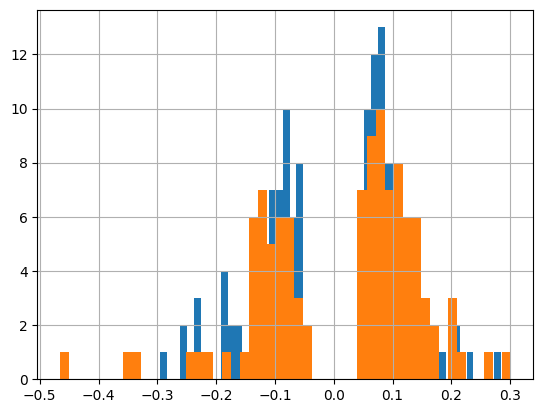

In [ ]:
df = pd.read_csv("/Volumes/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_catlas_with_all_peakfiles_variant_category_20260310_Bellenguez_AD_direction.csv",index_col=0)
df[df['Bellenguez_input_minor_allele_AD_direction']=="risk"]
df_risk = df[df['Bellenguez_input_minor_allele_AD_direction']=="risk"]
df_thp1=pd.read_csv("/Volumes/T7/mpra3_lib_analysis/allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240813_comparative_THP1Macrophage_alleleOnly.csv",index_col=0)
df_thp1
df_thp1_risk = df_thp1.loc[df_risk.index]
df_thp1_risk[df_thp1_risk['fdr']<=0.05]['logFC'].hist(bins=50)
df = pd.read_csv("/Volumes/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_catlas_with_all_peakfiles_variant_category_20260310_Bellenguez_AD_direction.csv",index_col=0)
df[df['Bellenguez_input_minor_allele_AD_direction']=="protective"]
df_risk = df[df['Bellenguez_input_minor_allele_AD_direction']=="protective"]
df_thp1=pd.read_csv("/Volumes/T7/mpra3_lib_analysis/allele_differences_withoutcontrol/20240817_allele_only_for_plotting/annotated_20240813_comparative_THP1Macrophage_alleleOnly.csv",index_col=0)
df_thp1
df_thp1_risk = df_thp1.loc[df_risk.index]
df_thp1_risk[df_thp1_risk['fdr']<=0.05]['logFC'].hist(bins=50)


In [40]:
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 46.7 MB/s  0:00:00 eta 0:00:01


In [41]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import binomtest, wilcoxon

# -----------------------------
# File paths
# -----------------------------

ANNOTATION_PATH = Path(
    "/Volumes/T7/mpra3_lib_analysis/indexing/"
    "SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_"
    "Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_catlas_"
    "with_all_peakfiles_variant_category_20260310_Bellenguez_AD_direction.csv"
)

THP1_PATH = Path(
    "/Volumes/T7/mpra3_lib_analysis/"
    "allele_differences_withoutcontrol/"
    "20240817_allele_only_for_plotting/"
    "annotated_20240813_comparative_THP1Macrophage_alleleOnly.csv"
)

DIRECTION_COL = "Bellenguez_input_minor_allele_AD_direction"

# -----------------------------
# Load data
# -----------------------------

df_annotation = pd.read_csv(ANNOTATION_PATH, index_col=0)
df_thp1 = pd.read_csv(THP1_PATH, index_col=0)

# Avoid index type mismatch, such as integer versus string.
df_annotation.index = df_annotation.index.astype(str)
df_thp1.index = df_thp1.index.astype(str)

annotation_cols = [DIRECTION_COL]

# Keep rsid if it is available.
if "rsid" in df_annotation.columns:
    annotation_cols.append("rsid")

# Join using the shared row index.
df_merged = df_thp1[["logFC", "fdr"]].join(
    df_annotation[annotation_cols],
    how="inner"
)

print(f"Annotation rows:       {len(df_annotation):,}")
print(f"THP-1 rows:            {len(df_thp1):,}")
print(f"Matched rows:          {len(df_merged):,}")

df_merged.head()

Annotation rows:       855
THP-1 rows:            855
Matched rows:          855


,logFC,fdr,Bellenguez_input_minor_allele_AD_direction,rsid
alt:cg03073402:SNPCENTER:chr19:42927676:C:G:42927563:42927789:42927676,0.037138,1.983951e-01,unresolved,cg03073402
alt:cg03169557:SNPCENTER:chr16:89598950:C:G:89598837:89599063:89598950,-0.132102,5.922923e-07,unresolved,cg03169557
alt:cg05030077:SNPCENTER:chr16:2255199:C:G:2255086:2255312:2255199,-0.086250,1.076680e-03,unresolved,cg05030077
alt:cg05066959:SNPCENTER:chr8:41519308:C:G:41519195:41519421:41519308,-0.069255,1.560580e-02,unresolved,cg05066959
alt:cg05228284:SNPCENTER:chr19:2720847:C:G:2720734:2720960:2720847,0.100701,2.255084e-02,unresolved,cg05228284


In [42]:
# Confirm this based on the original MPRA differential-analysis definition.
RAW_POSITIVE_MEANS_MINOR_DECREASES_ACTIVITY = True

df_merged["logFC"] = pd.to_numeric(
    df_merged["logFC"],
    errors="coerce"
)

df_merged["fdr"] = pd.to_numeric(
    df_merged["fdr"],
    errors="coerce"
)

# Keep only SNPs for which the Bellenguez minor-allele direction is resolved.
df_directional = df_merged[
    df_merged[DIRECTION_COL].isin(["risk", "protective"])
].copy()

# Standardize the raw value so that a positive value always means:
# the Minor allele decreases enhancer activity.
if RAW_POSITIVE_MEANS_MINOR_DECREASES_ACTIVITY:
    df_directional["minor_allele_decrease_logFC"] = df_directional["logFC"]
else:
    df_directional["minor_allele_decrease_logFC"] = -df_directional["logFC"]

# Convert all SNPs to the risk-allele direction.
#
# Minor allele is risk:
#     risk allele = Minor allele
#     use the original sign
#
# Minor allele is protective:
#     risk allele = Major allele
#     flip the sign
df_directional["risk_allele_aligned_logFC"] = np.where(
    df_directional[DIRECTION_COL].eq("risk"),
    df_directional["minor_allele_decrease_logFC"],
    -df_directional["minor_allele_decrease_logFC"]
)

df_directional[
    [
        "logFC",
        "fdr",
        DIRECTION_COL,
        "risk_allele_aligned_logFC"
    ]
].head(20)

,logFC,fdr,Bellenguez_input_minor_allele_AD_direction,risk_allele_aligned_logFC
alt:rs10030602:PEAKCENTER:chr4:112086886:G:A:112086668:112087168:112086918,-0.000870,9.830074e-01,protective,0.000870
alt:rs10034952:PEAKCENTER:chr4:14137554:A:G:14137502:14138020:14137622,-0.028093,4.408608e-01,protective,0.028093
alt:rs1004173:PEAKCENTER:chr6:47445017:C:T:47444925:47446243:47444993,-0.061537,6.854648e-03,risk,-0.061537
alt:rs1004173:PEAKCENTER:chr6:47445017:C:T:47445015:47446766:47445073,0.050017,3.465492e-02,risk,0.050017
alt:rs10079603:SNPCENTER:chr5:113562687:G:C:113562574:113562800:113562687,0.076571,1.609493e-03,protective,-0.076571
alt:rs1010322:PEAKCENTER:chr17:47338083:C:G:47337432:47338428:47338155,-0.100233,9.038562e-07,risk,-0.100233
alt:rs1010322:PEAKCENTER:chr17:47338083:C:G:47337487:47338325:47338107,-0.295457,3.808902e-42,risk,-0.295457
alt:rs10130373:PEAKCENTER:chr14:92466231:C:A:92465994:92466494:92466244,-0.016729,5.088745e-01,risk,-0.016729
alt:rs1017204:SNPCENTER:chr19:33879678:C:T:33879565:33879791:33879678,0.084414,1.076680e-03,risk,0.084414
alt:rs10199363:SNPCENTER:chr2:113083214:G:A:113083101:113083327:113083214,0.076519,1.389625e-03,risk,0.076519


In [43]:
FDR_CUTOFF = 0.05

df_sig = df_directional[
    (df_directional["fdr"] <= FDR_CUTOFF)
    & df_directional["risk_allele_aligned_logFC"].notna()
].copy()

print(f"Directional SNP rows:             {len(df_directional):,}")
print(f"Significant THP-1 SNP rows:        {len(df_sig):,}")
print()

print(
    df_sig[DIRECTION_COL]
    .value_counts()
    .rename_axis("Minor allele AD direction")
    .to_frame("Count")
)

Directional SNP rows:             576
Significant THP-1 SNP rows:        241

                           Count
Minor allele AD direction       
risk                         134
protective                   107


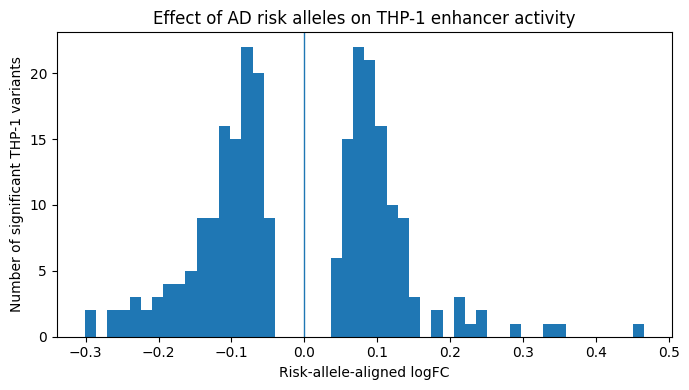

In [44]:
plt.figure(figsize=(7, 4))

plt.hist(
    df_sig["risk_allele_aligned_logFC"],
    bins=50
)

plt.axvline(0, linewidth=1)

plt.xlabel("Risk-allele-aligned logFC")
plt.ylabel("Number of significant THP-1 variants")
plt.title("Effect of AD risk alleles on THP-1 enhancer activity")

plt.tight_layout()
plt.show()

,Effect of AD risk allele,Count,Fraction
0,Decrease enhancer activity,114,0.473029
1,Increase enhancer activity,127,0.526971


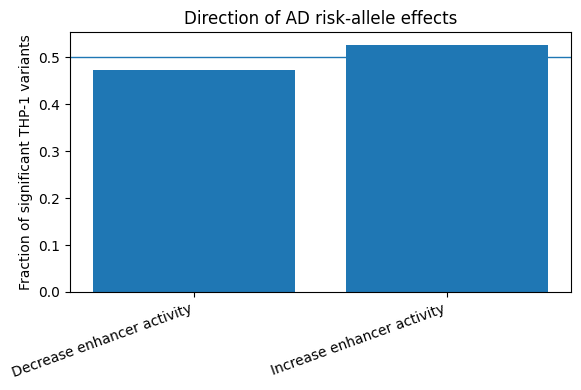

In [45]:
n_decrease = (
    df_sig["risk_allele_aligned_logFC"] > 0
).sum()

n_increase = (
    df_sig["risk_allele_aligned_logFC"] < 0
).sum()

n_zero = (
    df_sig["risk_allele_aligned_logFC"] == 0
).sum()

n_nonzero = n_decrease + n_increase

summary = pd.DataFrame(
    {
        "Effect of AD risk allele": [
            "Decrease enhancer activity",
            "Increase enhancer activity"
        ],
        "Count": [
            n_decrease,
            n_increase
        ]
    }
)

summary["Fraction"] = summary["Count"] / n_nonzero

display(summary)

plt.figure(figsize=(6, 4))

plt.bar(
    summary["Effect of AD risk allele"],
    summary["Fraction"]
)

plt.axhline(0.5, linewidth=1)

plt.ylabel("Fraction of significant THP-1 variants")
plt.title("Direction of AD risk-allele effects")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

,statistic,pval,fdr,df.test,df.dna,df.rna.full,df.rna.red,logFC,logFC_converted,RSID,Contributor,nearest_gene,rsID,chr_number,pos_hg38,ref,alt,AFR,AMR,ASN,EUR,MAF_Average,Rare_Common,Rare_Low_Common,GERP_cons,SiPhy_cons,Chromatin_States,Chromatin_States_Imputed,Chromatin_Marks,DNAse,Proteins,eQTL,gwas,grasp,Motifs,GENCODE_id,GENCODE_name,GENCODE_direction,GENCODE_distance,RefSeq_id,RefSeq_name,RefSeq_direction,RefSeq_distance,dbSNP_functional_annotation,query_snp_rsid,Promoter_histone_marks,Enhancer_histone_marks,snp_original,snp_original_haploreghg38,SNP_ID,...,ML_majormino_logFC_HEK293_ATAC_high_de,ML_majormino_logFC_Mouse_Cortex_AgeB-m,ML_majormino_logFC_Mouse_Cortex_AgeC-m,ML_majormino_logFC_Mouse_Striatum_AgeB,ML_majormino_logFC_Mouse_Striatum_AgeC,ML_majormino_logFC_THP1_IFNB-Calvin_20,ML_majormino_logFC_THP1_IFNG-Calvin_20,ML_majormino_logFC_THP1_LPSIFNG-Calvin,ML_majormino_logFC_THP1_Naive-Calvin_2,ML_majormino_logFC_THP1_monocyte0729_2,variant_id,Bellenguez_p_value,Bellenguez_p_value_negLog10,location,gene_name,closest_protein_coding_gene_TSS,distance_to_closest_protein_coding_TSS,hierarchical_label,rsid_gene_label,rsid_gene_tss,ML_majorminor_logFC_genomic_H1_IFNB-model,ML_majorminor_logFC_genomic_H1_resting-model,ML_majorminor_logFC_genomic_HEK293T_ATAC,ML_majorminor_logFC_genomic_HEK293_ATAC_high_depth0729,ML_majorminor_logFC_genomic_Mouse_Cortex_AgeB-model,ML_majorminor_logFC_genomic_Mouse_Cortex_AgeC-model,ML_majorminor_logFC_genomic_Mouse_Striatum_AgeB,ML_majorminor_logFC_genomic_Mouse_Striatum_AgeC,ML_majorminor_logFC_genomic_THP1_IFNB-Calvin,ML_majorminor_logFC_genomic_THP1_IFNG-Calvin,ML_majorminor_logFC_genomic_THP1_LPSIFNG-Calvin,ML_majorminor_logFC_genomic_THP1_Naive-Calvin,ML_majorminor_logFC_genomic_THP1_monocyte0729,ML_majorminor_logFC_genomic_WTC11_IFNB,ML_majorminor_logFC_genomic_WTC11_resting,ML_majorminor_diff_genomic_H1_IFNB-model,ML_majorminor_diff_genomic_H1_resting-model,ML_majorminor_diff_genomic_HEK293T_ATAC,ML_majorminor_diff_genomic_HEK293_ATAC_high_depth0729,ML_majorminor_diff_genomic_Mouse_Cortex_AgeB-model,ML_majorminor_diff_genomic_Mouse_Cortex_AgeC-model,ML_majorminor_diff_genomic_Mouse_Striatum_AgeB,ML_majorminor_diff_genomic_Mouse_Striatum_AgeC,ML_majorminor_diff_genomic_THP1_IFNB-Calvin,ML_majorminor_diff_genomic_THP1_IFNG-Calvin,ML_majorminor_diff_genomic_THP1_LPSIFNG-Calvin,ML_majorminor_diff_genomic_THP1_Naive-Calvin,ML_majorminor_diff_genomic_THP1_monocyte0729,ML_majorminor_diff_genomic_WTC11_IFNB,ML_majorminor_diff_genomic_WTC11_resting
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
alt:rs1004173:PEAKCENTER:chr6:47445017:C:T:47444925:47446243:47444993,9.552966,1.996266e-03,6.854648e-03,1,53,6,5,-0.061537,-0.061537,rs1004173,Pfenning,CD2AP,rs1004173,6,47477281,C,T,0.150,0.23,0.10,0.27,0.1875,Common,Common,0.0,0.0,NaN,NaN,"E001,H3K4me3_Pro;E002,H3K4me3_Pro;E003,H3K4me3_Pro;E004,H3K4me3_Pro;E005,H3K4me3_Pro;E006,H3K4me3_Pro;E007,H3K4me3_P...",E028;E032;E033;E034;E046;E050;E051;E056;E080;E081;E084;E085;E086;E088;E090;E091;E092;E093;E109;E122;E123;E126,.,"GTEx2015_v6,Brain_Cerebellar_Hemisphere,RP11-385F7.1,1.09880366244384e-08;GTEx2015_v6,Brain_Cerebellum,RP11-385F7.1,...",.,.,MZF1::1-4_2;Pax-4_3;STAT_disc7,ENSG00000198087.7,CD2AP,5.0,507.0,NM_012120,CD2AP,5.0,506.0,.,rs1004173,NaN,NaN,47445017,False,SNP_13,...,NaN,0.10,0.10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,rs1004173,8.010000e-12,11.096313,intergenic,NaN,CD2AP,508,promoter,rs1004173(CD2AP) promoter,rs1004173C:T (CD2AP),NaN,NaN,0.37,NaN,0.14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alt:rs1004173:PEAKCENTER:chr6:47445017:C:T:47445015:47446766:47445073,6.124109,1.333505e-02,3.465492e-02,1,53,6,5,0.050017,0.050017,rs1004173,Pfenning,CD2AP,rs1004173,6,47477281,C,T,0.150,0.23,0.10,0.27,0.1875,Common,Common,0.0,0.0,NaN,NaN,"E001,H3K4me3_Pro;E002,H3K4me3_Pro;E003,H3K4me3_Pro;E004,H3K4me3_Pro;E005,H3K4me3_Pro;E006,H3K4me3_Pr

In [1]:
# Next-step code for notebook 8.1: Bellenguez AD risk/non-risk allele vs transcription direction
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.stats import binomtest, wilcoxon, spearmanr
import matplotlib.pyplot as plt

BASE_DIR = Path("/Volumes/T7/mpra3_lib_analysis/indexing")
ANNOTATION_PATH = BASE_DIR / "SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_catlas_with_all_peakfiles_variant_category_20260310_Bellenguez_AD_direction.csv"
DIRECTION_COL = "Bellenguez_input_minor_allele_AD_direction"
BETA_COL = "Bellenguez_beta_input_minor_allele"

def sgn(x):
    if pd.isna(x) or x == 0: return 0
    return 1 if x > 0 else -1

def analyze_mpra(annotation_path, mpra_path, label, fdr_cutoff=0.05, contributors=None, gwas_p_cutoff=None):
    ann = pd.read_csv(annotation_path, low_memory=False).rename(columns={"Unnamed: 0":"row_id"})
    mpra = pd.read_csv(mpra_path, low_memory=False).rename(columns={"Unnamed: 0":"row_id"})
    ann["row_id"] = ann["row_id"].astype(str); mpra["row_id"] = mpra["row_id"].astype(str)
    m = mpra.merge(ann, on="row_id", how="inner", suffixes=("_mpra","_ann"))
    m["logFC_converted"] = pd.to_numeric(m["logFC_converted"], errors="coerce")
    m["fdr"] = pd.to_numeric(m["fdr"], errors="coerce")
    m[BETA_COL] = pd.to_numeric(m[BETA_COL], errors="coerce")
    m = m[m[DIRECTION_COL].isin(["risk", "protective"])].copy()
    if contributors is not None:
        m = m[m["Contributor"].isin(contributors)]
    if gwas_p_cutoff is not None:
        m["Bellenguez_p_value_new"] = pd.to_numeric(m["Bellenguez_p_value_new"], errors="coerce")
        m = m[m["Bellenguez_p_value_new"] < gwas_p_cutoff]
    m = m[(m["fdr"] <= fdr_cutoff) & m["logFC_converted"].notna() & m[BETA_COL].notna()].copy()
    # logFC_converted = log(Major/Minor). Positive means minor allele reduces transcription.
    # Positive risk_decrease_score means AD risk allele decreases transcription.
    m["risk_decrease_score"] = m[BETA_COL].map(sgn) * m["logFC_converted"]
    m["risk_allele_transcription_direction"] = np.where(m["risk_decrease_score"] > 0, "risk_decreases_transcription", np.where(m["risk_decrease_score"] < 0, "risk_increases_transcription", "zero"))
    m["variant_key"] = (m["rsid"].astype(str).str.lower()+"|"+m["chr"].astype(str)+":"+m["snp"].astype(str)+":"+m["a1"].astype(str)+":"+m["a2"].astype(str)+"|"+m["Major"].astype(str)+"/"+m["Minor"].astype(str))
    mv = m.sort_values(["fdr", "pval"], na_position="last").drop_duplicates("variant_key", keep="first")
    n_dec = (mv["risk_decrease_score"] > 0).sum(); n_inc = (mv["risk_decrease_score"] < 0).sum(); n = n_dec+n_inc
    print(f"{label}: {n_dec}/{n} ({n_dec/n:.1%}) AD risk alleles decrease transcription; binomial p={binomtest(n_dec,n).pvalue:.3g}")
    print("Spearman beta_minor vs logFC_converted:", spearmanr(mv[BETA_COL], mv["logFC_converted"], nan_policy="omit"))
    return mv

# Example calls. Replace with your actual MPRA paths.
# brain = analyze_mpra(ANNOTATION_PATH, BRAIN_MPRA_PATH, "Brain", fdr_cutoff=0.05)
# thp1 = analyze_mpra(ANNOTATION_PATH, THP1_MPRA_PATH, "THP1", fdr_cutoff=0.05)
# brain_pk = analyze_mpra(ANNOTATION_PATH, BRAIN_MPRA_PATH, "Brain Pfenning+Kellis", fdr_cutoff=0.05, contributors=["Pfenning","Kellis"])


In [3]:

brain = analyze_mpra("/Volumes/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_genomicML_logFC_diff_MAFCorrect_REFindex_catlas_with_all_peakfiles_variant_category_20260310_Bellenguez_AD_direction.csv", "/Volumes/T7/mpra3_lib_analysis/allele_differences_withoutcontrol/20240813_allele_only/20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv", "Brain", fdr_cutoff=0.05)
#thp1 = analyze_mpra(ANNOTATION_PATH, THP1_MPRA_PATH, "THP1", fdr_cutoff=0.05)
#rain_pk = analyze_mpra(ANNOTATION_PATH, BRAIN_MPRA_PATH, "Brain Pfenning+Kellis", fdr_cutoff=0.05, contributors=["Pfenning","Kellis"])


KeyError: 'logFC_converted'